# Tarea 1 Data Science For Social Network

- Integrante: Bryan Cabezas

## Limpieza y exportación

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt



In [2]:
plt.rcParams['text.usetex'] = False #para eliminar problemas de texto en plt

df_edges = pd.read_csv('edges_spotify.csv')
df_nodes = pd.read_csv('nodes_spotify.csv')

In [3]:
df_edges

,id_0,id_1
0,NGHTMRE,Lil Jon
1,Sick Luke,MACHETE
2,Mat.Joe,Hayden James
3,Faber,Stereo Luchs
4,Duki,LIT killah
...,...,...
129464,Wildstylez,MAKJ
129465,Carlos Rivera,José Luis Perales
129466,Sons Of Zion,Sid Diamond
129467,Lil Jon & The East Side Boyz,Lil Scrappy


In [4]:
df_edges.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129469 entries, 0 to 129468
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   id_0    129467 non-null  object
 1   id_1    129458 non-null  object
dtypes: object(2)
memory usage: 2.0+ MB


In [5]:
df_edges.isnull().sum()

id_0     2
id_1    11
dtype: int64

## Preprocesamiento

In [6]:
df_edges = df_edges.dropna(subset=['id_0', 'id_1']) #limpieza de los 13 nulos
df_edges['id_0'] = df_edges['id_0'].astype(str) #transformar a string
df_edges['id_1'] = df_edges['id_1'].astype(str)

edge_array = np.sort(df_edges[['id_0', 'id_1']].values, axis=1) #Ordenar los IDS para que A, B y B,A sean iguales
df_edges = pd.DataFrame(edge_array, columns=['id_0', 'id_1']).drop_duplicates() #Eliminamos duplicados

/var/folders/sp/c9kn72lj41q2vznpgf3wvmhc0000gn/T/ipykernel_4144/3382159322.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_edges['id_0'] = df_edges['id_0'].astype(str) #transformar a string
/var/folders/sp/c9kn72lj41q2vznpgf3wvmhc0000gn/T/ipykernel_4144/3382159322.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_edges['id_1'] = df_edges['id_1'].astype(str)


In [7]:
df_edges

,id_0,id_1
0,Lil Jon,NGHTMRE
1,MACHETE,Sick Luke
2,Hayden James,Mat.Joe
3,Faber,Stereo Luchs
4,Duki,LIT killah
...,...,...
129451,MAKJ,Wildstylez
129452,Carlos Rivera,José Luis Perales
129453,Sid Diamond,Sons Of Zion
129454,Lil Jon & The East Side Boyz,Lil Scrappy


In [8]:
df_edges

,id_0,id_1
0,Lil Jon,NGHTMRE
1,MACHETE,Sick Luke
2,Hayden James,Mat.Joe
3,Faber,Stereo Luchs
4,Duki,LIT killah
...,...,...
129451,MAKJ,Wildstylez
129452,Carlos Rivera,José Luis Perales
129453,Sid Diamond,Sons Of Zion
129454,Lil Jon & The East Side Boyz,Lil Scrappy


In [9]:
df_nodes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33078 entries, 0 to 33077
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   spotify_id  33078 non-null  object 
 1   name        33077 non-null  object 
 2   followers   33078 non-null  float64
 3   popularity  33078 non-null  int64  
 4   genres      33078 non-null  object 
 5   chart_hits  13245 non-null  object 
 6   n_genres    33078 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 1.8+ MB


In [10]:
df_edges.info()

<class 'pandas.core.frame.DataFrame'>
Index: 127098 entries, 0 to 129455
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   id_0    127098 non-null  object
 1   id_1    127098 non-null  object
dtypes: object(2)
memory usage: 2.9+ MB


In [11]:
df_nodes

,spotify_id,name,followers,popularity,genres,chart_hits,n_genres
0,4lDiJcOJ2GLCK6p9q5BgfK,Kontra K,1999676.0,72,"['christlicher rap', 'german hip hop']","['at (44)', 'de (111)', 'lu (22)', 'ch (31)', ...",2
1,652XIvIBNGg3C0KIGEJWit,Maxim,34596.0,36,[],['de (1)'],0
2,3dXC1YPbnQPsfHPVkm1ipj,Christopher Martin,249233.0,52,"['dancehall', 'lovers rock', 'modern reggae', ...","['at (1)', 'de (1)']",4
3,74terC9ol9zMo8rfzhSOiG,Jakob Hellman,21193.0,39,"['classic swedish pop', 'norrbotten indie', 's...",['se (6)'],3
4,71BhXa24Zf5zcikUb00l2N,Juice,11312.0,37,"['swedish drill', 'swedish hip hop', 'swedish ...",['se (4)'],4
...,...,...,...,...,...,...,...
33073,7aibxFH8hIlSUlXgshCgAP,Gidge,66205.0,42,"['electronica', 'italian electronica']",NaN,2
33074,5MAp6rMiUJjRLXMWtArXRS,Dorrough Music,60626.0,50,"['dfw rap', 'dirty south rap', 'gangster rap',...",NaN,6
33075,6QSwQEz8CDMg8Rqk8dEkxS,Mathame,93972.0,48,['italian techno'],NaN,1
33076,0By75sLZQ06mWyzNiSdLUB,Menor,26346.0,39,['funk carioca'],NaN,1


In [12]:
df_nodes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33078 entries, 0 to 33077
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   spotify_id  33078 non-null  object 
 1   name        33077 non-null  object 
 2   followers   33078 non-null  float64
 3   popularity  33078 non-null  int64  
 4   genres      33078 non-null  object 
 5   chart_hits  13245 non-null  object 
 6   n_genres    33078 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 1.8+ MB


In [13]:
# Conexión para tener los vinculos entre los nodos. Primero agregando las conexiones del artista 1
#df_artista1 = df_edges.merge(df_nodes, left_on='id_0', right_on='name', how='left') #left, porque nos importa los artista con conexiones, los que no tienen no importan.

#Conexión para tener la información del artista 2
#df_artista2 = df_artista1.merge(df_nodes, left_on='id_1', right_on='name', how="left", suffixes=('_artista1', '_artista2')) # El sufijo es para diferenciar las columnas de cada artista
#
#OTRA ALTERNATIVA

In [14]:
#df_artista2 = df_artista2.drop(columns=['chart_hits_artista1', 'chart_hits_artista2']) # Eliminamos las columnas de chart_hits porque no son relevantes para el análisis de la red
#df_artista2

In [15]:
#df_artista2['name_artista1'].isnull().sum() # No hay nulos en el nombre del artista 1
#df_artista2['name_artista2'].isnull().sum() # No hay nulos en el nombre del artista 2

## Creación del grafo

In [16]:
# Se crea el grafo vacío y se añade las aristas desde df_edges
G = nx.Graph()
G.add_edges_from(zip(df_edges['id_0'], df_edges['id_1']))

# Se preparan los datos de df_nodes para ser compatible como atributo de gephi
df_nodes['chart_hits'] = df_nodes['chart_hits'].fillna("0")
df_nodes['popularity'] = pd.to_numeric(df_nodes['popularity'], errors='coerce').fillna(0)
df_nodes['followers'] = pd.to_numeric(df_nodes['followers'], errors='coerce').fillna(0)

# Se convierte df_nodes en un diccionario para inyectarlo al grafo
df_nodes_unique = df_nodes.drop_duplicates(subset=['name']).set_index('name')
dict_atributos = df_nodes_unique.to_dict('index')

# Se agrega al grafo los atributos al grafo
nx.set_node_attributes(G, dict_atributos)

In [17]:
print(G.get_edge_data('Lil Jon', 'NGHTMRE'))

{}


## Creación de la EGO red

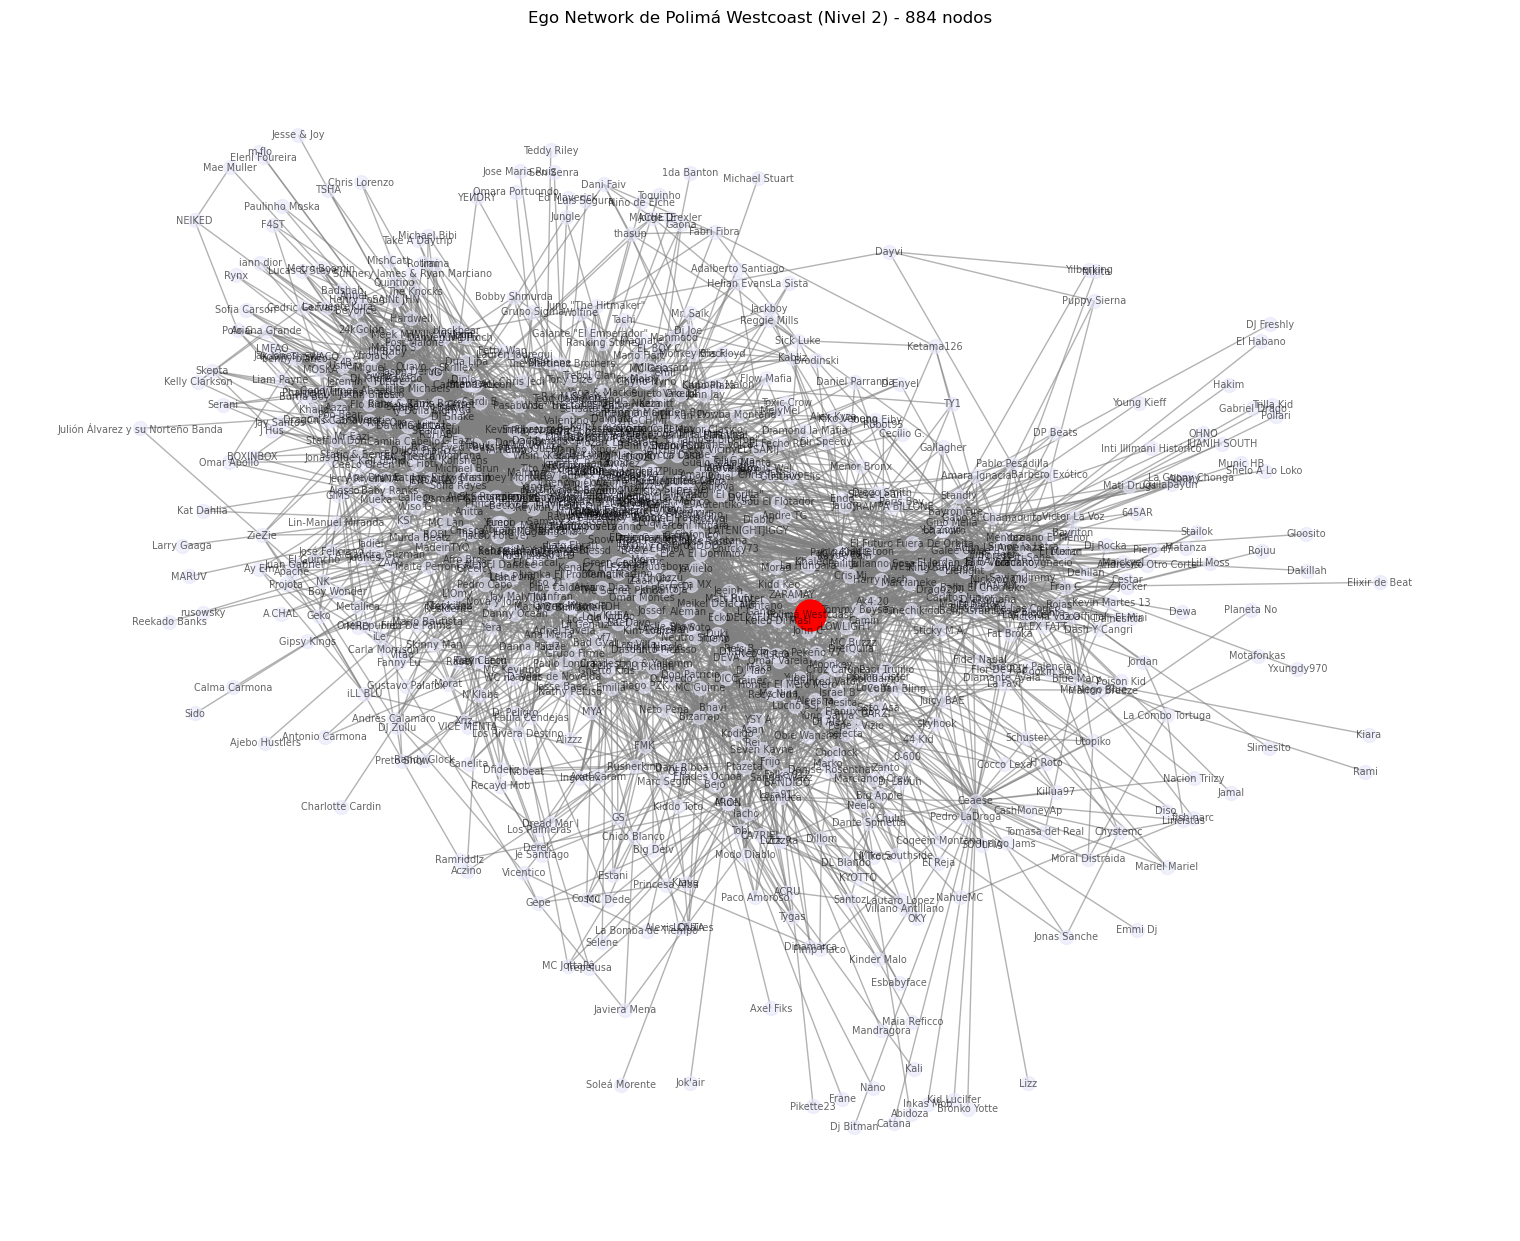

Nodos totales: 884
Información red: 884 nodos y 8591 aristas.


In [18]:
# Creación de la EGO red
ego = "Polimá Westcoast"  
nivel = 2

egoNet_artista = nx.ego_graph(G, ego, radius=nivel) #se agrega el nivel de la ego red
num_nodos = len(egoNet_artista.nodes())

# Validación de la tarea
if num_nodos < 500 or num_nodos > 10000:
    print(f" Error: La red de {ego} tiene {num_nodos} nodos.")
    raise ValueError("Número de nodos fuera de rango.") 

plt.figure(figsize=(15, 12))
pos = nx.spring_layout(egoNet_artista, k=0.15, seed=1)

# Se omite los signos $ para no dar error en la visualización
labels_seguras = {n: str(n).replace('$', r'\$') for n in egoNet_artista.nodes()}

nx.draw(egoNet_artista, pos, 
        node_color="lavender", 
        node_size=100, 
        with_labels=True, 
        labels=labels_seguras,
        font_size=7,
        edge_color="gray",
        alpha=0.6)


nx.draw_networkx_nodes(egoNet_artista, pos, nodelist=[ego], node_size=500, node_color="red")
plt.title(f"Ego Network de {ego} (Nivel {nivel}) - {num_nodos} nodos")
plt.show()

nodos_mj = len(egoNet_artista.nodes())
aristas_mj = len(egoNet_artista.edges())
print(f"Nodos totales: {num_nodos}")
print(f"Información red: {nodos_mj} nodos y {aristas_mj} aristas.")

## Guardado

In [ ]:
# Exportación a Gephi
# # Limpieza final de tipos de datos para que el formato GEXF sea válido
for n in egoNet_artista.nodes():
    attrs = egoNet_artista.nodes[n]
    for key, value in attrs.items():
        if isinstance(value, list):
            egoNet_artista.nodes[n][key] = "|".join(map(str, value)) #se convierte la lista en string con separador
        elif pd.isnull(value):
            egoNet_artista.nodes[n][key] = "N/A"

# Guardar archivo
nombre_archivo = f"egoNet_{ego.replace(' ', '_')}_N{nivel}.gexf"
nx.write_gexf(egoNet_artista, nombre_archivo)

nodos_mj = len(egoNet_artista.nodes())
aristas_mj = len(egoNet_artista.edges())
print(f"Nodos totales: {num_nodos}")
print(f"Archivo generado: {nombre_archivo}")

Nodos totales: 884
Archivo generado: egoNet_Polimá_Westcoast_N2d.gexf
